# **Notebook 1: Exploratory Data Analysis (EDA)**


> **Objective:** Perform initial data profiling on the raw data to justify our preprocessing decisions, followed by deep exploratory analysis on the `final_dataset_clean` to uncover actionable business insights and guide Machine Learning feature selection.
the Exploratory Analysis section of this notebook aims at obtaining the most information about our data to better judge what techniques will be required regarding the possibility of missing values and outliers as well as what transformations will be made to the data to improve its usability.


---

## **Table of Contents**
1. [Imports and Data Loading](#1-imports)
2. [Structural Overview & Data Types](#2-structure)
3. [Missing Values Analysis](#3-missing)
4. [Univariate Analysis: Finding the Anomalies](#4-univariate)
5. [Bivariate Analysis: Baseline Relationships](#5-bivariate)
6. [Action Plan for Preprocessing](#6-actionplan)

---

## **1. Imports and Libraries** <a id="1-imports"></a>


In [54]:

%load_ext autoreload
%autoreload 2

import base64
from IPython.display import IFrame, display

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from mapclassify import classify

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')


import sys 
sys.path.append("../src") 

from eda import plot_missing_values, plot_distribution, plot_pie_chart

# Load the RAW datasets
raw_customer = pd.read_csv('../data/customer_info.csv', index_col=0)
raw_basket = pd.read_csv('../data/customer_basket.csv')

print(f"Raw Customer Shape: {raw_customer.shape}")
print(f"Raw Basket Shape: {raw_basket.shape}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Raw Customer Shape: (33038, 24)
Raw Basket Shape: (100000, 3)


<a id="2-load"></a>
## **2. Structural Overview and Datatypes**

> The first step is to get a **good understanding** of the data we're working with. We will start by analyzing more general information

### **Our Datasets**

In [36]:
raw_customer.head()

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [37]:
raw_basket.head()

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


### **Datatypes**

In [39]:
raw_customer.dtypes

customer_name                                  str
customer_gender                                str
customer_birthdate                             str
kids_home                                  float64
teens_home                                 float64
number_complaints                          float64
distinct_stores_visited                    float64
lifetime_spend_groceries                   float64
lifetime_spend_electronics                 float64
typical_hour                               float64
lifetime_spend_vegetables                  float64
lifetime_spend_nonalcohol_drinks           float64
lifetime_spend_alcohol_drinks              float64
lifetime_spend_meat                        float64
lifetime_spend_fish                        float64
lifetime_spend_hygiene                     float64
lifetime_spend_videogames                  float64
lifetime_spend_petfood                     float64
lifetime_total_distinct_products           float64
percentage_of_products_bought_p

In [40]:
raw_basket.dtypes

invoice_id       int64
list_of_goods      str
customer_id      int64
dtype: object

### **General Info**

In [41]:
raw_customer.describe().T

,count,mean,std,min,25%,50%,75%,max
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000
lifetime_spend_alcohol_drinks,32708.0,622.144185,517.744320,0.000000,201.000000,483.000000,891.250000,3704.000000


In [42]:
raw_basket.describe().T

,count,mean,std,min,25%,50%,75%,max
invoice_id,100000.0,6.155483e+06,3.532964e+06,20023.0,3111465.25,6162339.0,9212398.75,12242204.0
customer_id,100000.0,2.003460e+04,1.154614e+04,3.0,10026.00,20018.0,30047.00,40000.0


In [43]:
raw_customer.describe(include='O').T

,count,unique,top,freq
customer_name,33038,32543,Susan Smith,5
customer_gender,33038,2,female,16577
customer_birthdate,32873,32852,11/03/1998 06:10 PM,2


In [44]:
raw_basket.describe(include='O').T

,count,unique,top,freq
list_of_goods,100000,99784,"['energy bar', 'airpods']",5


<a id="3-missing"></a>
## **3. Missing Value Analysis**

> Moving on to the missing value analysis

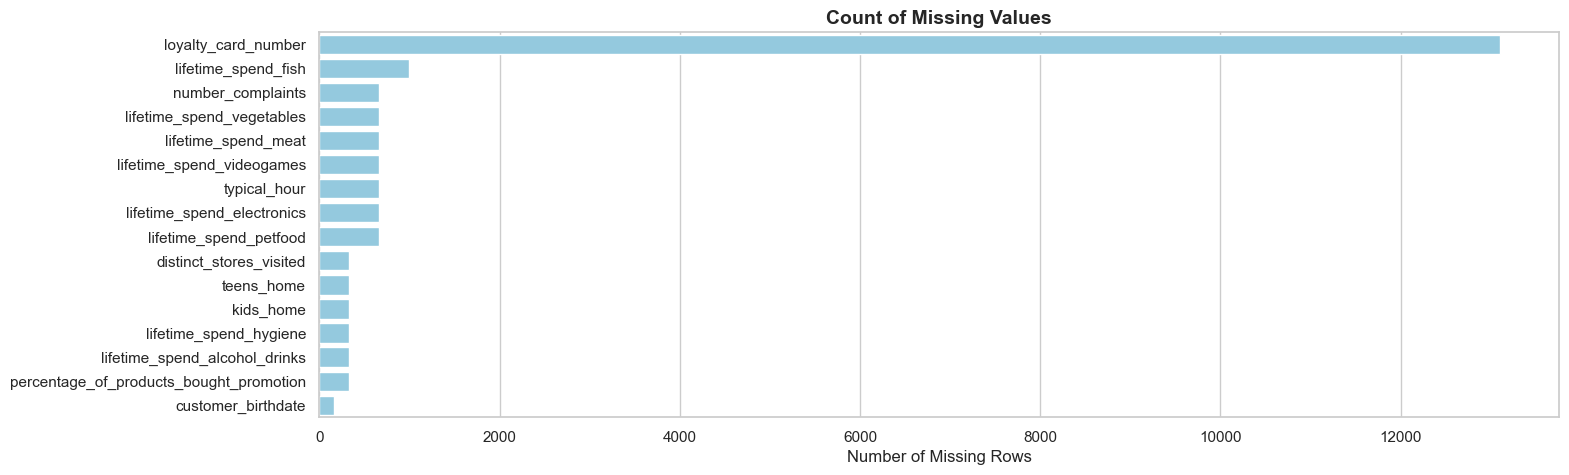

In [38]:
plot_missing_values(raw_customer, 'Count of Missing Values')

<a id="3-missing"></a>
## **4. Variables Distribution**

> Moving on to the missing value analysis

### **Distributions**

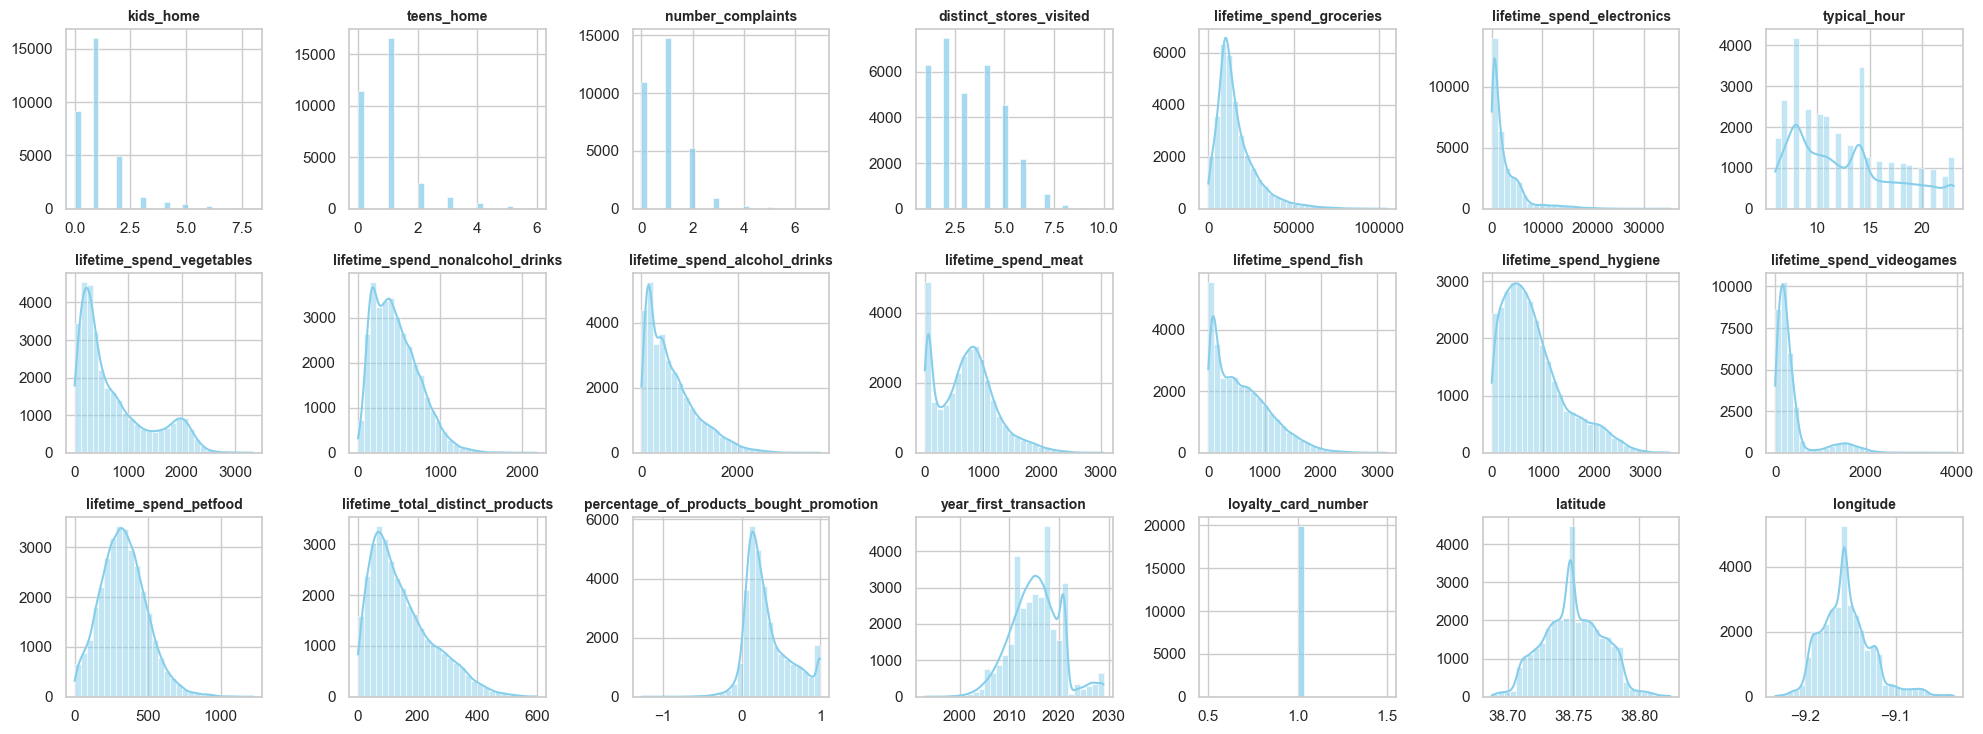

In [45]:
plot_distribution(raw_customer)

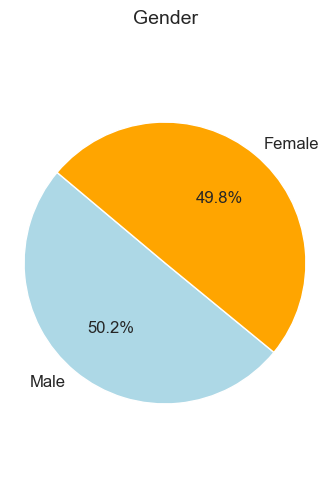

In [53]:
plot_pie_chart(raw_customer, variable='customer_gender', colors=['lightblue', 'orange'], legend=['Male', 'Female'], title_= "Gender")

<a id="3-missing"></a>
## **6. Geo Analysis**

> Moving on to the missing value analysis

In [47]:
data_geo = gpd.GeoDataFrame(raw_customer, geometry = gpd.points_from_xy(raw_customer['longitude'], raw_customer['latitude'], crs = '4236'))

In [55]:
sample_data = data_geo.sample(1200, random_state=42)
full_data = data_geo
m = sample_data.explore()
n = full_data.explore()
n.save("full_dataset_map.html")
html_content = m.get_root().render()
encoded = base64.b64encode(html_content.encode('utf-8')).decode('utf-8')
data_uri = f"data:text/html;charset=utf-8;base64,{encoded}"
display(IFrame(src=data_uri, width="100%", height=500))